# Stage 2 — אימון מודל לקריאת שעון דיגיטלי

בשלב הזה נאמן מודל שמקבל תמונה של שעון דיגיטלי ומחזיר שלוש תחזיות:

1. שעה — hour  
2. דקה — minute  
3. שנייה — second  

כלומר המודל לומד לזהות את הזמן מתוך התמונה הדיגיטלית.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from sklearn.model_selection import train_test_split

## הגדרות בסיס ונתיבים

כאן נגדיר איפה נמצא הדאטה, כמה דוגמאות נעבד בכל Batch, כמה Epochs נאמן, ומהו ה־Device שבו נשתמש: GPU אם קיים, אחרת CPU.

In [2]:
BASE_DIR = Path("clock_project")
DATA_DIR = BASE_DIR / "data"
LABELS_PATH = DATA_DIR / "labels.csv"

BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Labels path:", LABELS_PATH)
print("Labels exists:", LABELS_PATH.exists())

Using device: cpu
Labels path: clock_project\data\labels.csv
Labels exists: True


## טעינת קובץ התוויות

נטען את labels.csv שיצרנו בשלב 1.  
הקובץ מכיל לכל דוגמה את נתיבי התמונות ואת התוויות: שעה, דקה ושנייה.

In [3]:
df = pd.read_csv(LABELS_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 7)


,sample_id,digital_image_path,analog_with_hands_path,analog_clean_path,hour,minute,second
0,0,clock_project\data\digital\digital_00000.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,4,11,10
1,1,clock_project\data\digital\digital_00001.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,23,55,46
2,2,clock_project\data\digital\digital_00002.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,17,53,50
3,3,clock_project\data\digital\digital_00003.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,3,52,59
4,4,clock_project\data\digital\digital_00004.png,clock_project\data\analog_with_hands\analog_ha...,clock_project\data\analog_clean\analog_clean_0...,17,17,6


## חלוקה ל־Train ו־Validation

נחלק את הדאטה לשני חלקים:

1. Train — לאימון המודל  
2. Validation — לבדיקה האם המודל באמת לומד ולא רק זוכר

נשתמש ב־80% לאימון ו־20% לבדיקה.

In [4]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))

Train size: 800
Validation size: 200


## Transform לתמונות

כאן נגדיר איך התמונות ייכנסו למודל:

- Resize ל־224x224
- המרה ל־Tensor

זה הפורמט שה־ResNet מצפה לקבל.

In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

## Dataset Class

ניצור מחלקה שמלמדת את PyTorch איך לקרוא כל דוגמה:

- לפתוח את תמונת השעון הדיגיטלי
- להחזיר את התמונה
- להחזיר את hour / minute / second בתור labels

In [6]:
class DigitalClockDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = row["digital_image_path"]
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        hour = torch.tensor(int(row["hour"]), dtype=torch.long)
        minute = torch.tensor(int(row["minute"]), dtype=torch.long)
        second = torch.tensor(int(row["second"]), dtype=torch.long)

        return image, hour, minute, second

## DataLoaders

כאן ניצור DataLoader עבור train ועבור validation.

ה־DataLoader אחראי לקחת את הדאטה בקבוצות קטנות שנקראות batches, כדי שהמודל יוכל להתאמן בצורה יעילה.

In [7]:
train_dataset = DigitalClockDataset(
    train_df,
    transform=transform
)

val_dataset = DigitalClockDataset(
    val_df,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders ready")
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

DataLoaders ready
Train batches: 25
Validation batches: 7


In [8]:
images, hours, minutes, seconds = next(iter(train_loader))

print("Images shape:", images.shape)
print("Hours shape:", hours.shape)
print("Minutes shape:", minutes.shape)
print("Seconds shape:", seconds.shape)

print("Example label:")
print(f"{hours[0].item():02d}:{minutes[0].item():02d}:{seconds[0].item():02d}")

Images shape: torch.Size([32, 3, 224, 224])
Hours shape: torch.Size([32])
Minutes shape: torch.Size([32])
Seconds shape: torch.Size([32])
Example label:
05:40:08


## בניית המודל

נשתמש ב־ResNet18 כ־backbone.

המודל יקבל תמונת שעון דיגיטלי ויחזיר 3 תחזיות נפרדות:

1. hour → 24 classes  
2. minute → 60 classes  
3. second → 60 classes

כלומר שלושה heads נפרדים מעל אותו backbone.

In [9]:
class DigitalTimeReader(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.resnet18(pretrained=True)

        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.hour_head = nn.Linear(num_features, 24)
        self.minute_head = nn.Linear(num_features, 60)
        self.second_head = nn.Linear(num_features, 60)

    def forward(self, x):
        features = self.backbone(x)

        hour_pred = self.hour_head(features)
        minute_pred = self.minute_head(features)
        second_pred = self.second_head(features)

        return hour_pred, minute_pred, second_pred

In [11]:
model = DigitalTimeReader().to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Model ready")


Model ready


## אימון המודל + מדדי Accuracy

בשלב הזה נאמן את המודל ונמדוד:

- Loss על train
- Loss על validation
- Accuracy של שעה
- Accuracy של דקה
- Accuracy של שנייה
- Accuracy מלא — רק אם שלושתם נכונים יחד

In [12]:
history = {
    "train_loss": [],
    "val_loss": [],
    "hour_acc": [],
    "minute_acc": [],
    "second_acc": [],
    "full_time_acc": []
}

for epoch in range(EPOCHS):
    # ---------- TRAIN ----------
    model.train()
    train_loss = 0

    for images, hours, minutes, seconds in train_loader:
        images = images.to(DEVICE)
        hours = hours.to(DEVICE)
        minutes = minutes.to(DEVICE)
        seconds = seconds.to(DEVICE)

        optimizer.zero_grad()

        pred_hour, pred_minute, pred_second = model(images)

        loss_hour = criterion(pred_hour, hours)
        loss_minute = criterion(pred_minute, minutes)
        loss_second = criterion(pred_second, seconds)

        loss = loss_hour + loss_minute + loss_second

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss = train_loss / len(train_loader)

    # ---------- VALIDATION ----------
    model.eval()
    val_loss = 0

    correct_hour = 0
    correct_minute = 0
    correct_second = 0
    correct_full_time = 0
    total = 0

    with torch.no_grad():
        for images, hours, minutes, seconds in val_loader:
            images = images.to(DEVICE)
            hours = hours.to(DEVICE)
            minutes = minutes.to(DEVICE)
            seconds = seconds.to(DEVICE)

            pred_hour, pred_minute, pred_second = model(images)

            loss_hour = criterion(pred_hour, hours)
            loss_minute = criterion(pred_minute, minutes)
            loss_second = criterion(pred_second, seconds)

            loss = loss_hour + loss_minute + loss_second
            val_loss += loss.item()

            hour_preds = torch.argmax(pred_hour, dim=1)
            minute_preds = torch.argmax(pred_minute, dim=1)
            second_preds = torch.argmax(pred_second, dim=1)

            correct_hour += (hour_preds == hours).sum().item()
            correct_minute += (minute_preds == minutes).sum().item()
            correct_second += (second_preds == seconds).sum().item()

            full_correct = (
                (hour_preds == hours) &
                (minute_preds == minutes) &
                (second_preds == seconds)
            )

            correct_full_time += full_correct.sum().item()
            total += images.size(0)

    val_loss = val_loss / len(val_loader)

    hour_acc = correct_hour / total
    minute_acc = correct_minute / total
    second_acc = correct_second / total
    full_time_acc = correct_full_time / total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["hour_acc"].append(hour_acc)
    history["minute_acc"].append(minute_acc)
    history["second_acc"].append(second_acc)
    history["full_time_acc"].append(full_time_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Hour Acc: {hour_acc:.3f} | "
        f"Minute Acc: {minute_acc:.3f} | "
        f"Second Acc: {second_acc:.3f} | "
        f"Full Time Acc: {full_time_acc:.3f}"
    )

Epoch 1/10 | Train Loss: 9.3104 | Val Loss: 8.6348 | Hour Acc: 0.570 | Minute Acc: 0.125 | Second Acc: 0.120 | Full Time Acc: 0.000
Epoch 2/10 | Train Loss: 4.5523 | Val Loss: 5.0500 | Hour Acc: 0.815 | Minute Acc: 0.530 | Second Acc: 0.570 | Full Time Acc: 0.260
Epoch 3/10 | Train Loss: 1.9246 | Val Loss: 2.6358 | Hour Acc: 0.955 | Minute Acc: 0.850 | Second Acc: 0.840 | Full Time Acc: 0.665
Epoch 4/10 | Train Loss: 0.7422 | Val Loss: 1.6715 | Hour Acc: 0.995 | Minute Acc: 0.905 | Second Acc: 0.950 | Full Time Acc: 0.860
Epoch 5/10 | Train Loss: 0.3264 | Val Loss: 1.0657 | Hour Acc: 1.000 | Minute Acc: 0.925 | Second Acc: 0.930 | Full Time Acc: 0.855
Epoch 6/10 | Train Loss: 0.1621 | Val Loss: 0.6721 | Hour Acc: 1.000 | Minute Acc: 0.975 | Second Acc: 0.985 | Full Time Acc: 0.960
Epoch 7/10 | Train Loss: 0.0938 | Val Loss: 0.5030 | Hour Acc: 1.000 | Minute Acc: 0.990 | Second Acc: 0.985 | Full Time Acc: 0.975
Epoch 8/10 | Train Loss: 0.0645 | Val Loss: 0.4411 | Hour Acc: 1.000 | Minut

## שמירת המודל והיסטוריית האימון

נשמור את המודל המאומן לקובץ, וגם נשמור את מדדי האימון לקובץ CSV כדי שיהיה לנו תיעוד מסודר.

In [13]:
MODELS_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIR / "digital_time_reader.pth"
HISTORY_PATH = RESULTS_DIR / "digital_reader_training_history.csv"

torch.save(model.state_dict(), MODEL_PATH)

history_df = pd.DataFrame(history)
history_df.to_csv(HISTORY_PATH, index=False)

print("Model saved to:", MODEL_PATH)
print("History saved to:", HISTORY_PATH)

history_df

Model saved to: clock_project\models\digital_time_reader.pth
History saved to: clock_project\results\digital_reader_training_history.csv


,train_loss,val_loss,hour_acc,minute_acc,second_acc,full_time_acc
0,9.310368,8.634831,0.570,0.125,0.120,0.000
1,4.552265,5.049977,0.815,0.530,0.570,0.260
2,1.924620,2.635796,0.955,0.850,0.840,0.665
3,0.742164,1.671466,0.995,0.905,0.950,0.860
4,0.326389,1.065677,1.000,0.925,0.930,0.855
5,0.162115,0.672125,1.000,0.975,0.985,0.960
6,0.093832,0.502990,1.000,0.990,0.985,0.975
7,0.064467,0.441060,1.000,0.980,0.990,0.970
8,0.050548,0.381767,1.000,0.990,0.995,0.985
9,0.040150,0.326812,1.000,0.995,0.995,0.990


## גרפים של האימון

נציג את ה־Loss ואת מדדי ה־Accuracy לאורך ה־Epochs.

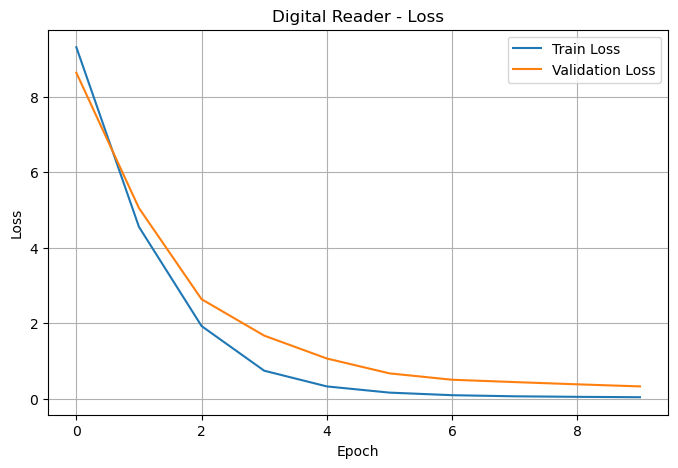

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["train_loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Digital Reader - Loss")
plt.legend()
plt.grid(True)
plt.show()

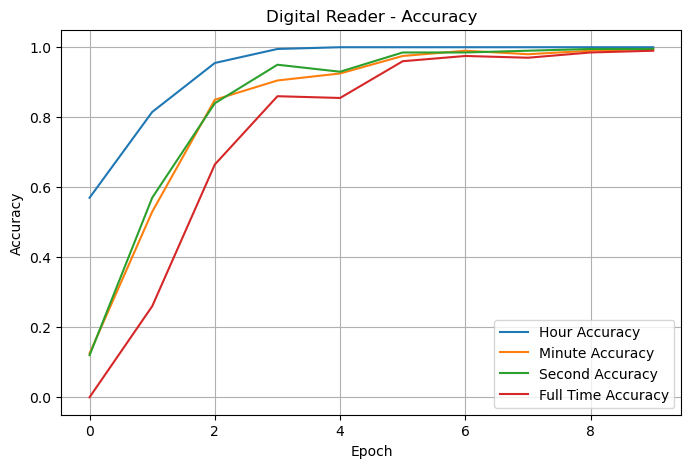

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["hour_acc"], label="Hour Accuracy")
plt.plot(history_df["minute_acc"], label="Minute Accuracy")
plt.plot(history_df["second_acc"], label="Second Accuracy")
plt.plot(history_df["full_time_acc"], label="Full Time Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Digital Reader - Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## בדיקת חיזוי על דוגמה אחת

ניקח תמונה אחת מה־validation set ונבדוק האם המודל מצליח לקרוא את השעה.

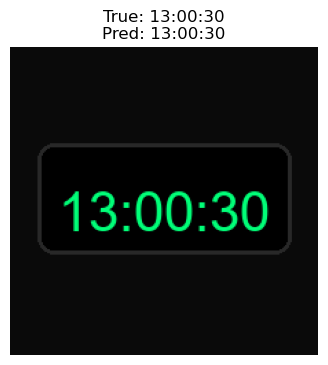

In [16]:
model.eval()

sample = val_df.sample(1).iloc[0]
image = Image.open(sample["digital_image_path"]).convert("RGB")

input_tensor = transform(image).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    pred_hour, pred_minute, pred_second = model(input_tensor)

pred_hour = torch.argmax(pred_hour, dim=1).item()
pred_minute = torch.argmax(pred_minute, dim=1).item()
pred_second = torch.argmax(pred_second, dim=1).item()

true_hour = int(sample["hour"])
true_minute = int(sample["minute"])
true_second = int(sample["second"])

plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"True: {true_hour:02d}:{true_minute:02d}:{true_second:02d}\n"
    f"Pred: {pred_hour:02d}:{pred_minute:02d}:{pred_second:02d}"
)
plt.show()